In [1]:
import yaml
import numpy as np
import os
import pandas as pd
from os.path import join as pjoin
from glob import glob
from pathlib import Path
import matplotlib.pyplot as plt
from skimage import io
from skimage.transform import resize
from scipy.ndimage import gaussian_filter
from scipy.spatial import procrustes
from scipy.optimize import minimize
import scipy.io as sio

In [2]:
def load_config(config_path):
    """load the YAML config"""
    with open(config_path, "r") as f:
        config = yaml.safe_load(f)
    return config

/Volumes/Data_attention/Transfer learning/LinShu/DATA_linshu/000 Widefield/A095/20250821
Experiments found: ['20250821-214508']
[11.757  5.938  5.931 11.692  5.949  5.872  5.897 11.651  5.895  5.891
  5.961  5.928 11.687 11.718  5.992 11.685 11.918 11.795  6.021 11.715
  6.024  6.008 11.711 11.668  6.017  6.074 11.748 11.796 11.673  6.034
  6.104 11.664 11.759  6.13   6.144  6.104  6.123  6.123 11.837 11.966
 11.897  6.208  6.163  6.208  6.185 11.86  11.855 11.925  6.264  6.219
  6.233  6.266 11.92   6.313  6.244  6.31  11.929  6.269  6.295 11.901
 11.921  6.314 11.962 11.888 11.989 12.019  6.352  6.316 12.019 12.045
  6.356 12.014  6.381 11.959 12.05  12.032  6.405  6.412  6.354  6.438
 12.104 12.147 12.095  6.484 12.089 12.233  6.521 12.202  6.552 12.175
 12.202  6.573  6.587  6.546 12.18  12.248  6.562  6.544 12.245  6.554
  6.599  6.597  6.597  6.629 12.287  6.653  6.663  6.638 12.428 12.418
 12.409  6.725 12.43  12.393  6.755  6.75   6.718 12.395 12.47   6.724
  6.786 12.515  6.76

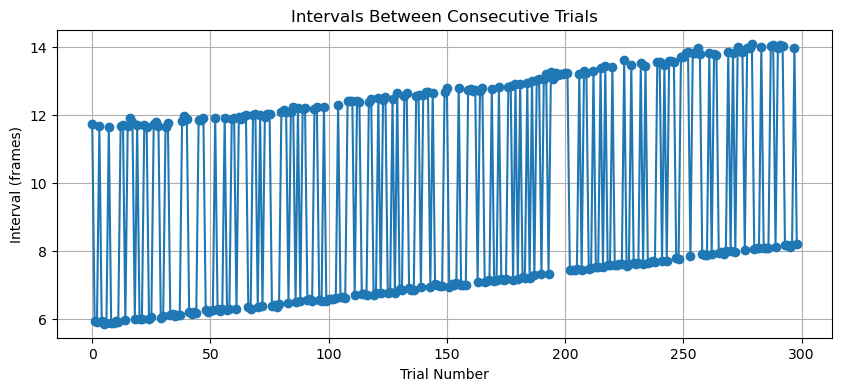

300
Generated trial_onsets_wf.npy for 20250821-214508
Shapes match.
[11.7574  5.9378  5.9317 11.6915  5.9497  5.8725  5.8965 11.6519  5.8945
  5.8914  5.9608  5.9288 11.6869 11.7181  5.9927 11.6856 11.9177 11.7954
  6.0208 11.7159  6.0245  6.0081 11.7114 11.6678  6.0169  6.0747 11.7477
 11.797  11.6734  6.0338  6.1045 11.6642 11.7594  6.1296  6.1446  6.1042
  6.1233  6.1229 11.8371 11.9665 11.8971  6.2084  6.1632  6.2084  6.185
 11.8597 11.8555 11.9254  6.2642  6.219   6.2339  6.2653 11.9205  6.3134
  6.2445  6.3101 11.9293  6.2687  6.2952 11.9014 11.9214  6.3137 11.9626
 11.8886 11.9894 12.0193  6.3517  6.3162 12.0199 12.0446  6.3562 12.0145
  6.3814 11.9593 12.0501 12.033   6.4048  6.4118  6.355   6.4373 12.1045
 12.1478 12.095   6.4841 12.0898 12.2325  6.5221 12.2015  6.5529 12.1745
 12.203   6.5725  6.5877  6.5459 12.1806 12.2486  6.562   6.5437 12.2459
  6.5539  6.5991  6.5975  6.5972  6.6286 12.2878  6.6535  6.6624  6.6386
 12.4283 12.4181 12.4097  6.7253 12.4299 12.3933  6.7556 

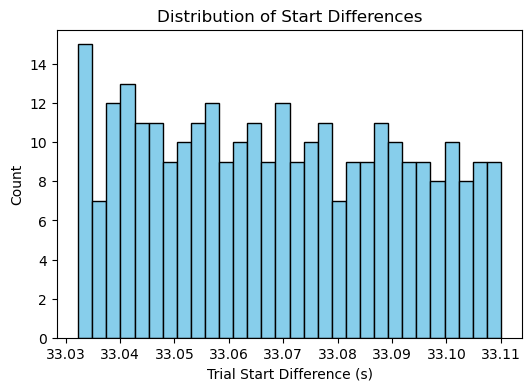

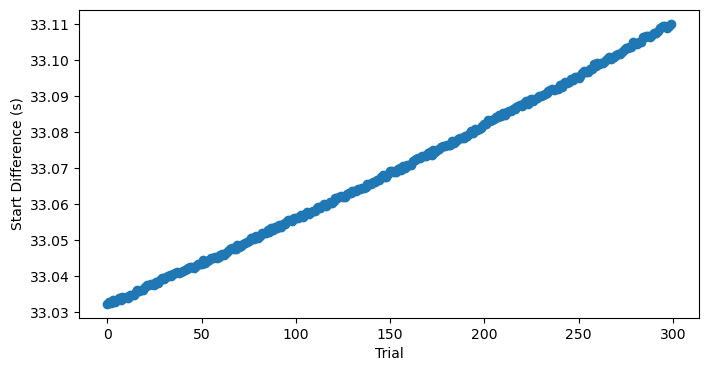

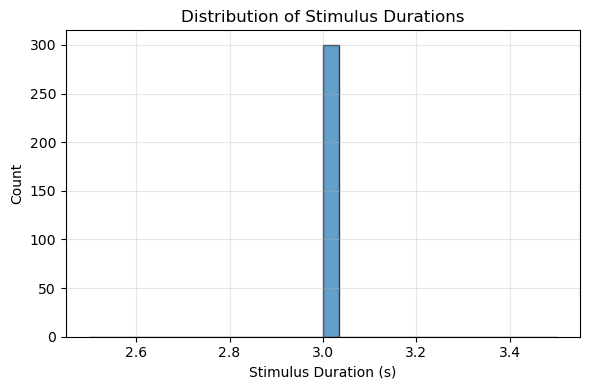

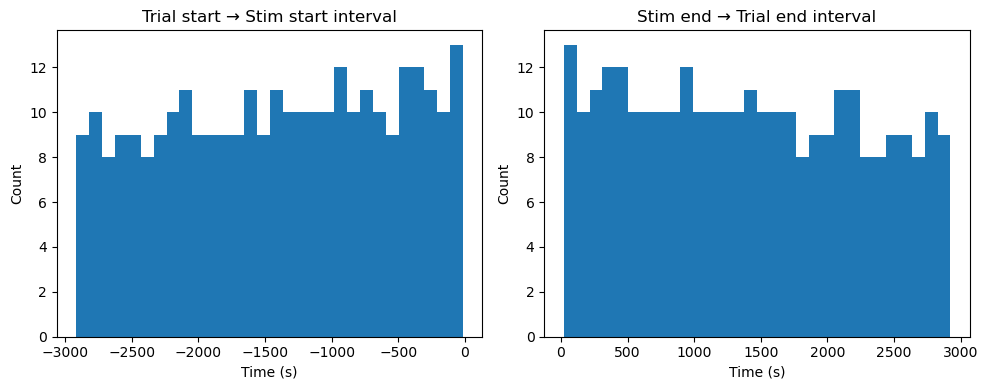

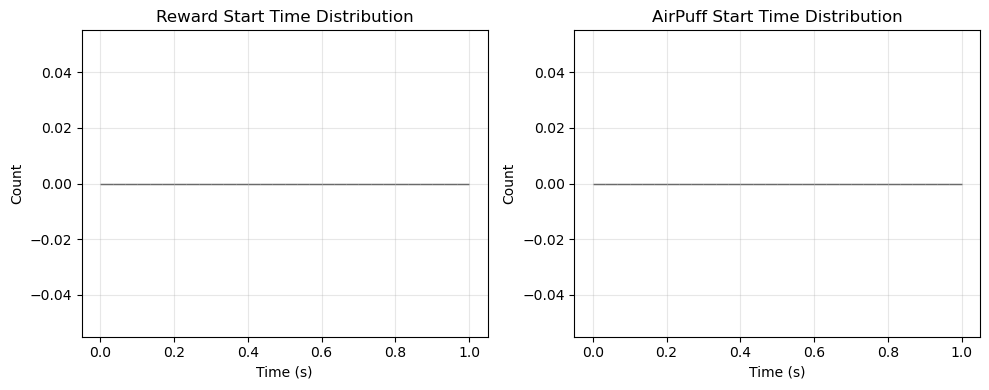

Generated stim_timestamp.npy, reward timestamps.npy, airpuff_timestamps.npy for 20250821-214508
Generated lick_timestamps.npy for 20250821-214508
Generated widefield_timestamps_blue.npy, widefield_timestamps_violet.npy for 20250821-214508
Generated all time files for 20250821-214508
----------------------------------------
/Volumes/Data_attention/Transfer learning/LinShu/DATA_linshu/000 Widefield/A095/20250822
Experiments found: ['20250822-182151']
[ 5.958 11.503  5.869  5.887  5.797  5.887 11.424  5.86   5.881 11.427
  5.895 11.35   5.86   5.905 11.394  5.915 11.599  5.956  5.962  5.965
  5.935 11.682  5.938  5.978 11.534 11.536 11.552  5.996 11.458  6.01
  6.005  6.005  6.004  6.036 11.613 11.592  6.018  6.086  5.998  6.073
 11.685  6.108 11.562 11.646 11.694  6.138 11.707 11.847  6.118  6.136
  6.146 11.862  6.151  6.279  6.191 11.88  11.784  6.251  6.156  6.116
  6.159  6.194  6.171 11.661 11.616 11.574 11.585  6.166 11.624 11.623
 11.669 11.684  6.223  6.22  11.56  11.649  6.227 1

<Figure size 640x480 with 0 Axes>

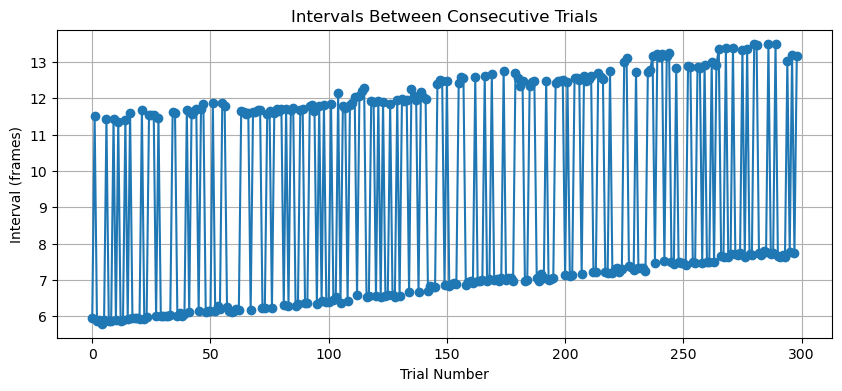

300
Generated trial_onsets_wf.npy for 20250822-182151
Shapes match.
[ 5.9582 11.5033  5.8688  5.887   5.7972  5.8877 11.4236  5.861   5.8807
 11.4271  5.8952 11.3503  5.8599  5.9056 11.3948  5.9146 11.5991  5.9563
  5.962   5.9657  5.9353 11.6819  5.938   5.9787 11.5337 11.5367 11.5517
  5.9971 11.4582  6.0099  6.0051  6.0054  6.0038  6.036  11.6138 11.5924
  6.0178  6.0863  5.9983  6.0728 11.6851  6.1089 11.5622 11.6464 11.6937
  6.1382 11.7075 11.8473  6.1178  6.1366  6.1457 11.8627  6.1511  6.2791
  6.191  11.8811 11.7836  6.2516  6.1561  6.1163  6.1594  6.1934  6.1713
 11.662  11.6163 11.5742 11.5854  6.1661 11.6241 11.6228 11.6695 11.6846
  6.2233  6.2198 11.5602 11.6497  6.2273 11.6052 11.7016 11.6435 11.6969
  6.3097 11.6952  6.2833 11.6706 11.7198  6.2975  6.3306 11.6725 11.7003
  6.3544  6.3714 11.8001 11.8025 11.6393  6.3529 11.7748  6.4089 11.8231
  6.3867  6.405  11.839   6.4485  6.541  12.1358  6.3791 11.779  11.736
  6.4258 11.8249 11.8796 12.0357  6.5952 12.0585 12.2039 

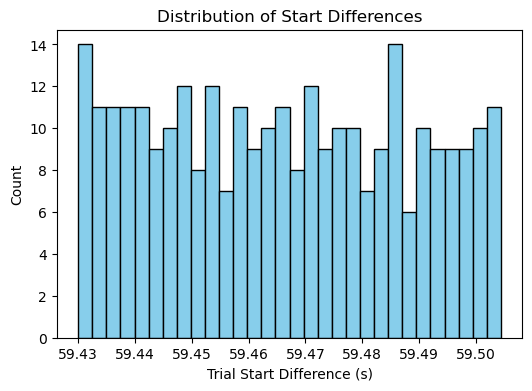

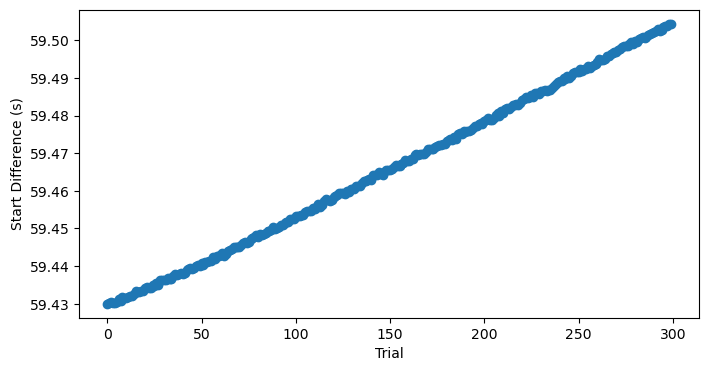

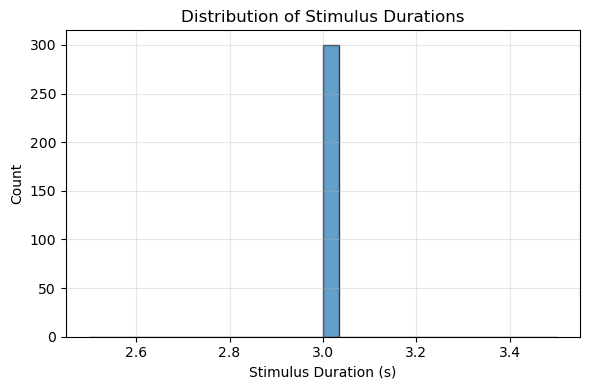

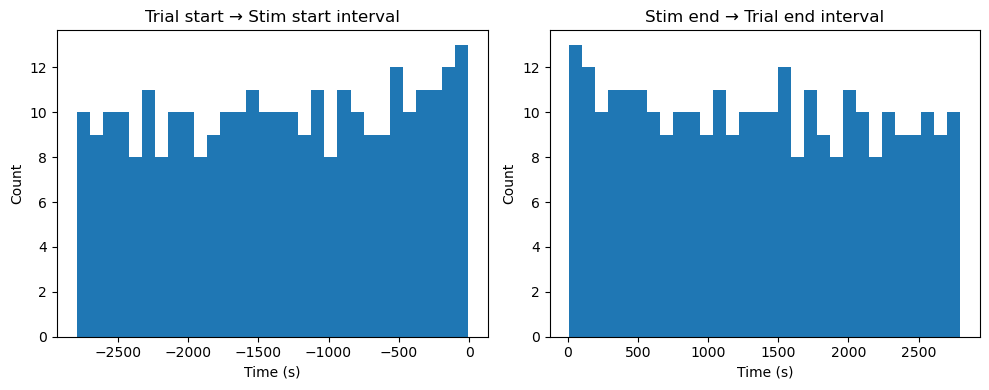

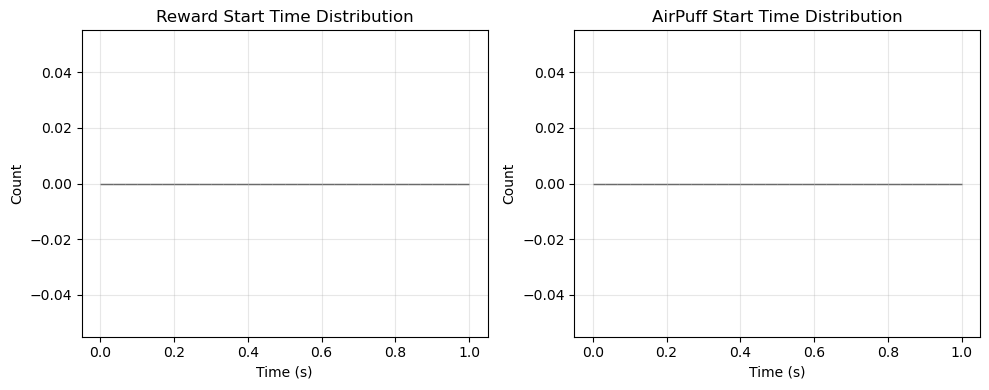

Generated stim_timestamp.npy, reward timestamps.npy, airpuff_timestamps.npy for 20250822-182151
Generated lick_timestamps.npy for 20250822-182151
Generated widefield_timestamps_blue.npy, widefield_timestamps_violet.npy for 20250822-182151
Generated all time files for 20250822-182151
----------------------------------------
/Volumes/Data_attention/Transfer learning/LinShu/DATA_linshu/000 Widefield/A095/20250825
Experiments found: ['20250825-215012']
[ 6.902  6.853 14.98   6.871  6.854 14.568  6.843 14.484  6.907  6.917
  6.876  6.902 14.814 14.73   6.952  6.959  6.941 14.845 14.815 14.724
  6.932  6.963  6.948  6.963 14.702  7.089  7.041  7.057  7.105 14.8
  7.053 14.782  7.131  7.112  7.052 14.918 14.934  7.092  7.223  7.233
 15.397 15.294  7.294 15.159 15.209  7.362 15.275 15.513  7.411  7.422
  7.436 15.258 15.404 15.481  7.42  15.53  15.26  15.411 15.232  7.505
  7.397  7.568 15.277  7.509 15.33  15.188 15.284 15.223  7.584  7.554
  7.624 15.237 15.472  7.588  7.679  7.685 15.658  7

<Figure size 640x480 with 0 Axes>

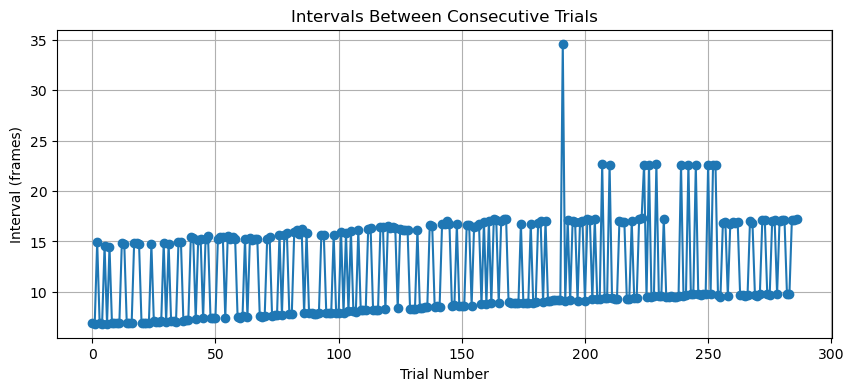

288
Generated trial_onsets_wf.npy for 20250825-215012
Shapes match.
[ 6.9027  6.8533 14.9807  6.871   6.8542 14.5678  6.8434 14.4848  6.9066
  6.9175  6.8763  6.9018 14.8145 14.7304  6.9528  6.959   6.9412 14.8451
 14.8155 14.7239  6.9324  6.9631  6.9486  6.9634 14.7025  7.0883  7.0417
  7.0574  7.1051 14.8006  7.0529 14.7821  7.1316  7.1118  7.0524 14.9183
 14.9341  7.0923  7.2237  7.2327 15.3974 15.2952  7.2938 15.1593 15.2094
  7.3627 15.275  15.5132  7.4114  7.4218  7.4368 15.2582 15.4046 15.4814
  7.4199 15.531  15.2597 15.412  15.2325  7.5051  7.3968  7.568  15.2775
  7.5098 15.33   15.1885 15.2845 15.2229  7.5843  7.5544  7.6239 15.2374
 15.4731  7.5883  7.6786  7.6853 15.6585  7.7367 15.6482 15.8618  7.8402
  7.8103 15.951  16.1695 15.7735 16.2024  7.9204 15.8626  7.9385  7.8815
  7.8321  7.8437  7.8898 15.6839 15.6244  7.8616  7.9347  7.8934 15.6681
  7.9352  7.9419 15.9485  7.9117 15.8286  8.0882 16.0348  8.0958  8.0335
 16.101   8.1602  8.204   8.165  16.194  16.2925  8.1924

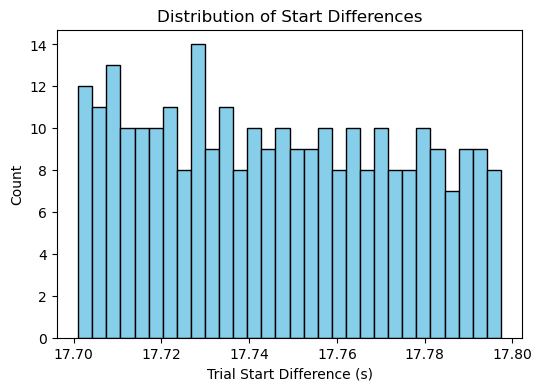

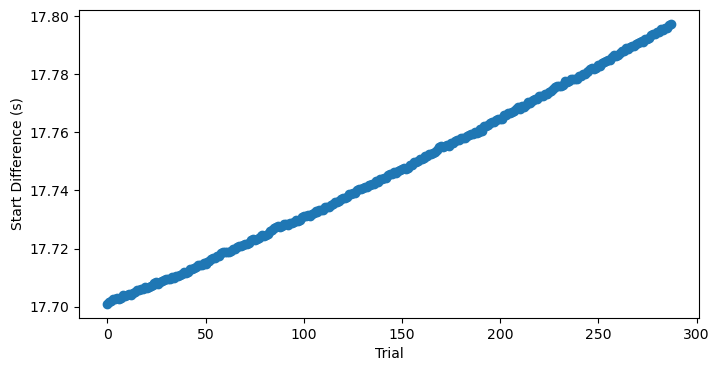

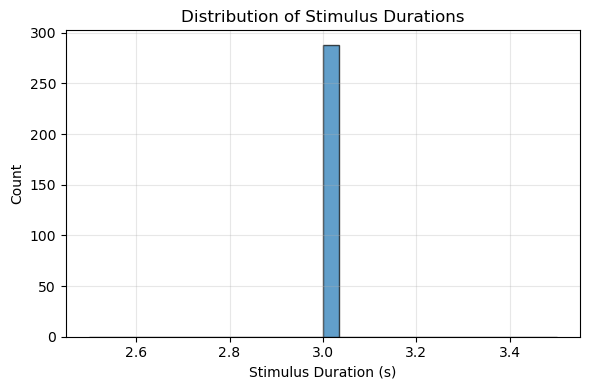

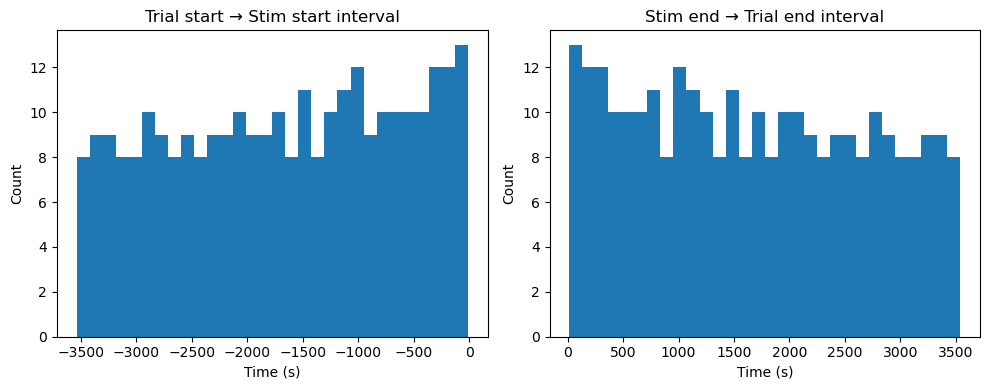

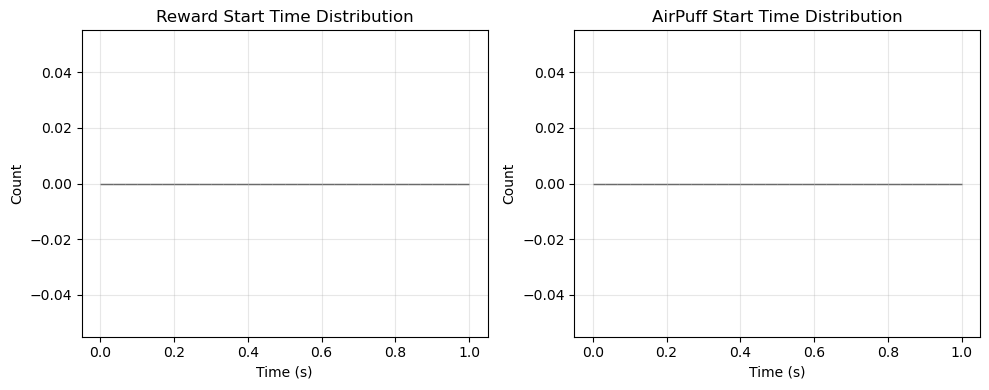

Generated stim_timestamp.npy, reward timestamps.npy, airpuff_timestamps.npy for 20250825-215012
Generated lick_timestamps.npy for 20250825-215012
Generated widefield_timestamps_blue.npy, widefield_timestamps_violet.npy for 20250825-215012
Generated all time files for 20250825-215012
----------------------------------------
/Volumes/Data_attention/Transfer learning/LinShu/DATA_linshu/000 Widefield/A095/20250826
Experiments found: ['20250826-200618']
[ 6.537  6.474  6.517  6.559 13.407 13.861  6.553  6.488  6.47  13.804
  6.593 13.57   6.563  6.63  13.937  6.612 13.461  6.693 14.029 13.648
 14.004  6.767  6.707  6.568  6.614  6.704 13.852 13.832  6.749 13.781
 13.771 13.909  6.871  6.817  6.767 13.631  6.908  6.823  6.879 13.668
  6.902  6.943  6.922  6.807 13.729  7.009  6.983  6.887  6.704 13.719
  6.97   6.94   6.964  6.91  14.285 14.352 14.288  7.08   7.124 14.304
 14.228 14.426  7.091 14.143 14.329 14.305  7.17   7.17  14.512 13.965
  7.214 14.477  7.237  7.231 14.505 14.662 14.499 

<Figure size 640x480 with 0 Axes>

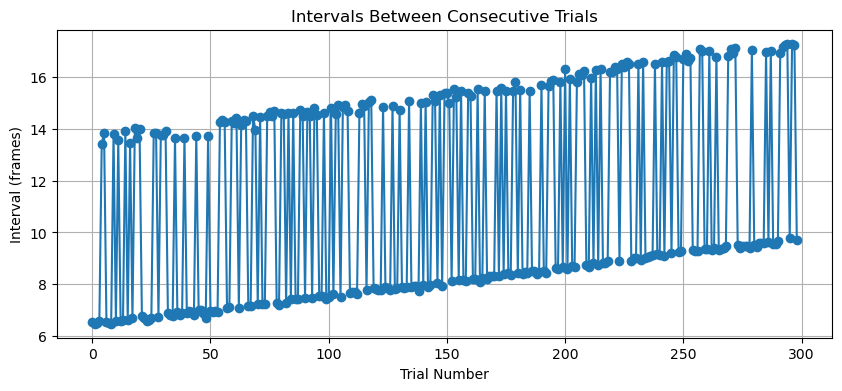

300
Generated trial_onsets_wf.npy for 20250826-200618
Shapes match.
[ 6.5373  6.4739  6.5173  6.5595 13.4067 13.8618  6.5532  6.4882  6.4696
 13.805   6.5934 13.57    6.5627  6.6303 13.9374  6.6124 13.4617  6.6932
 14.0289 13.6484 14.0044  6.7677  6.7073  6.5673  6.6146  6.7045 13.8524
 13.8323  6.7491 13.7816 13.7705 13.91    6.8712  6.8173  6.7671 13.6314
  6.9082  6.8232  6.879  13.6683  6.9021  6.9431  6.9228  6.8072 13.7288
  7.0094  6.9835  6.8869  6.7039 13.7192  6.9705  6.9406  6.9638  6.9103
 14.285  14.3527 14.288   7.0808  7.1235 14.3049 14.2282 14.4263  7.0912
 14.1436 14.3294 14.3051  7.1707  7.1701 14.5127 13.9646  7.215  14.477
  7.2368  7.2316 14.5054 14.6621 14.5    14.6901  7.2587  7.2038 14.6104
 14.5929  7.2624 14.6193  7.4312 14.6352  7.4284  7.4417 14.7493 14.4918
  7.4642 14.6565 14.502   7.4785 14.8254 14.5377  7.5322  7.5361 14.6161
  7.4414  7.5001 14.8169  7.6009 14.5628 14.9089  7.4903 14.8491 14.9177
 14.6954  7.6726  7.6823  7.6809  7.6183 14.6334 14.9541 

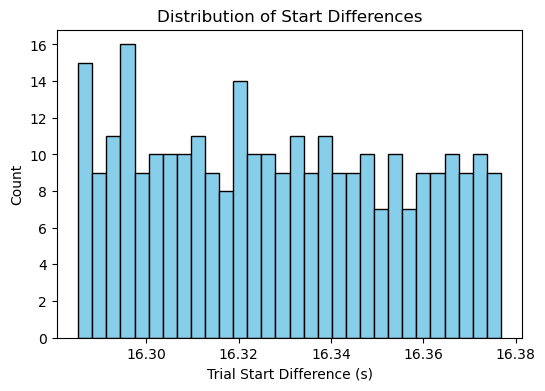

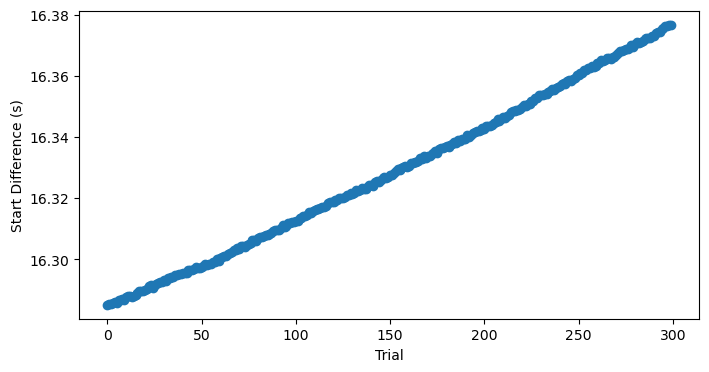

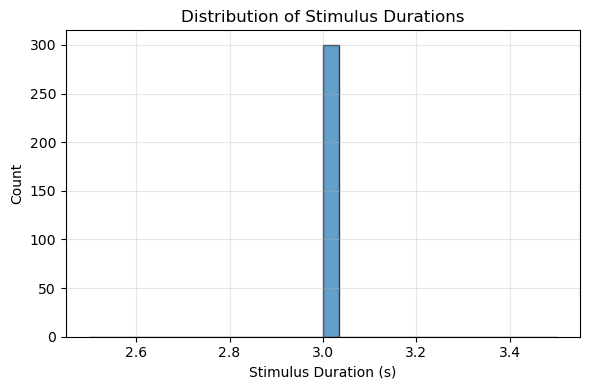

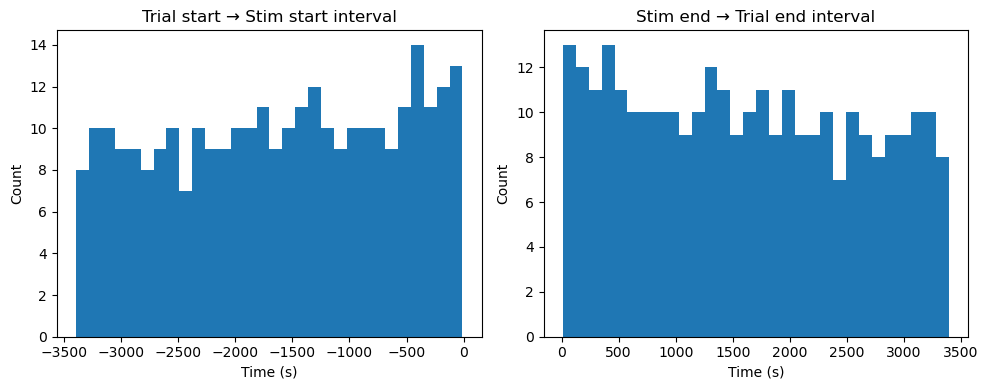

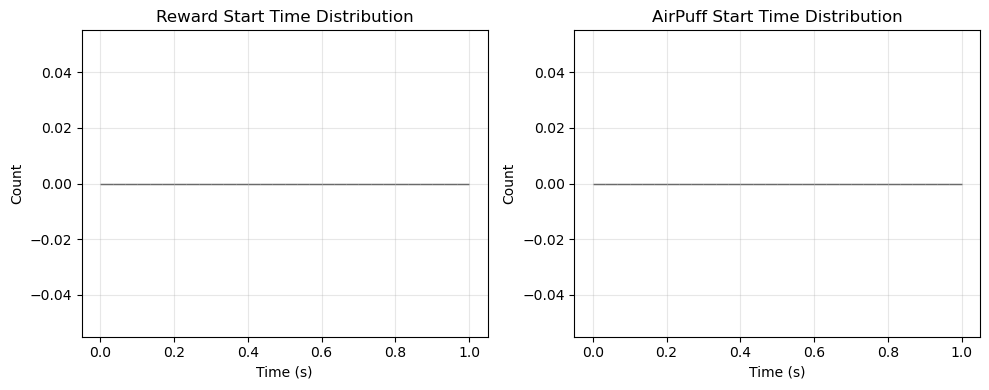

Generated stim_timestamp.npy, reward timestamps.npy, airpuff_timestamps.npy for 20250826-200618
Generated lick_timestamps.npy for 20250826-200618
Generated widefield_timestamps_blue.npy, widefield_timestamps_violet.npy for 20250826-200618
Generated all time files for 20250826-200618
----------------------------------------
/Volumes/Data_attention/Transfer learning/LinShu/DATA_linshu/000 Widefield/A095/20250901
Experiments found: ['20250901-175445']
[ 6.198 12.5    6.191 12.072  6.153  6.21   6.196 12.269 12.292  6.253
  6.218 12.246  6.08  12.562  6.309  6.19  12.016 12.522  6.319  6.179
 12.057  6.277  6.299 12.585  6.134  6.157 12.53  12.607 12.117  6.37
  6.395 12.527  6.253  6.3    6.373 12.777  6.245  6.207 12.482  6.498
  6.44   6.369 12.299 12.703  6.436  6.267  6.382 12.722  6.501  6.419
  6.288 12.427  6.592  6.548 12.376 12.458 12.904  6.477 12.414 12.923
  6.649  6.463  6.428  6.531  6.649  6.691  6.601  6.503 12.597  6.701
  6.645  6.5    6.519  6.573 13.031  6.758  6.475 1

<Figure size 640x480 with 0 Axes>

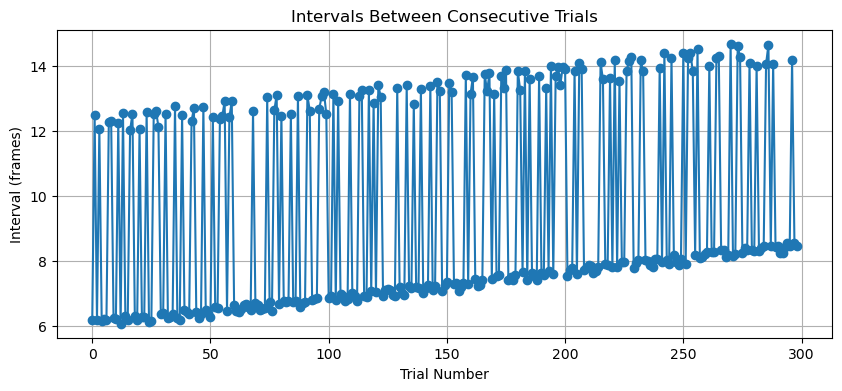

300
Generated trial_onsets_wf.npy for 20250901-175445
Shapes match.
[ 6.1982 12.5004  6.191  12.0723  6.1534  6.2103  6.1965 12.2688 12.2929
  6.2527  6.218  12.2468  6.0796 12.5626  6.3092  6.19   12.0164 12.5229
  6.3193  6.1789 12.0571  6.2768  6.2996 12.5852  6.1341  6.1576 12.5304
 12.6075 12.1168  6.3699  6.3953 12.5271  6.2534  6.3004  6.3731 12.7771
  6.2453  6.2069 12.4826  6.4982  6.4399  6.3697 12.2991 12.7039  6.4354
  6.268   6.3815 12.7225  6.5009  6.42    6.2873 12.4276  6.5925  6.5479
 12.3767 12.4581 12.9043  6.477  12.4144 12.9231  6.6497  6.4626  6.4288
  6.5311  6.6493  6.6908  6.6014  6.5031 12.5974  6.7014  6.6454  6.4995
  6.5195  6.5726 13.0318  6.758   6.4755 12.6301 13.1037  6.7    12.4638
  6.7706  6.7518  6.7657 12.5047  6.7491  6.7748 13.0658  6.6029  6.7027
  6.7607 13.0905 12.6246  6.8026  6.8369  6.8814 12.6704 13.0579 13.1883
 12.5153  6.8577  6.9232 13.14    6.8072 12.9174  7.0065  6.9373  6.7903
  6.8333 13.1204  7.0346  6.918   6.772  13.0856 13.2481

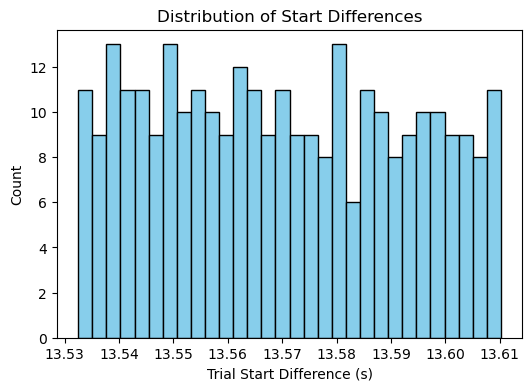

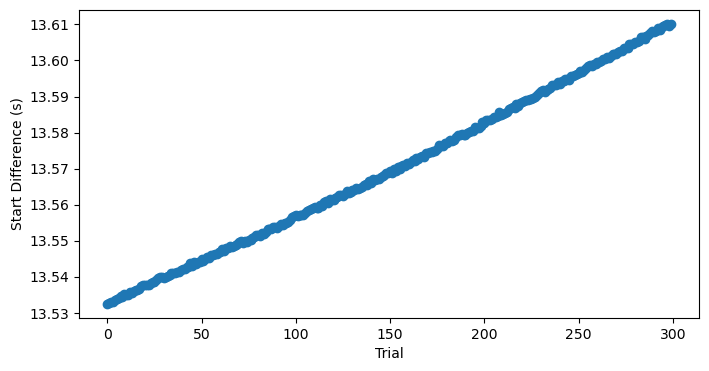

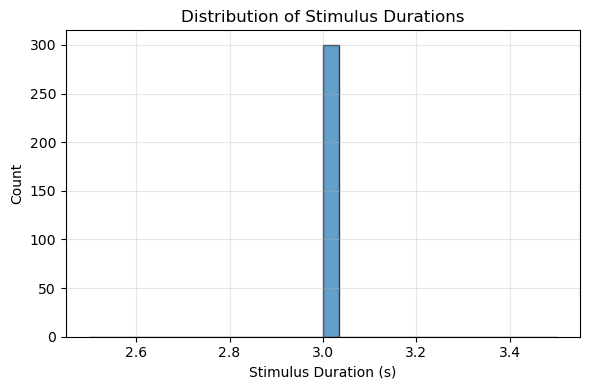

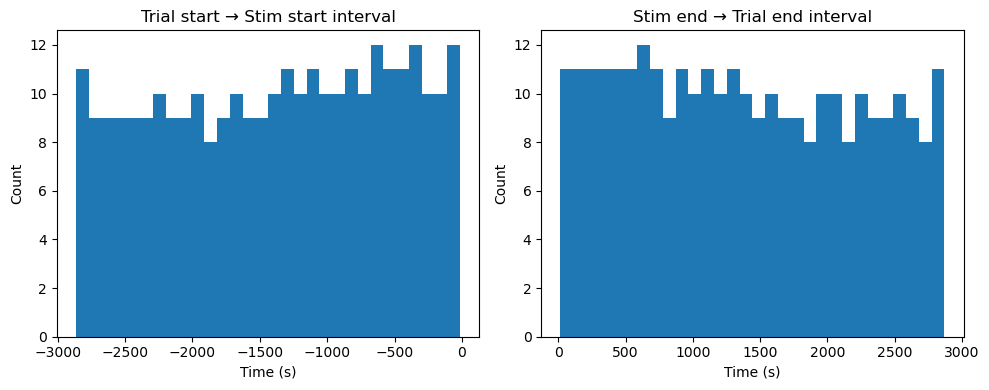

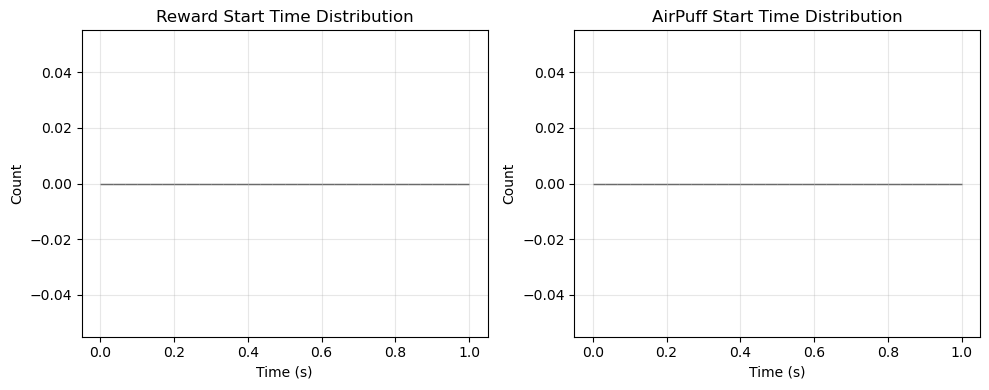

Generated stim_timestamp.npy, reward timestamps.npy, airpuff_timestamps.npy for 20250901-175445
Generated lick_timestamps.npy for 20250901-175445
Generated widefield_timestamps_blue.npy, widefield_timestamps_violet.npy for 20250901-175445
Generated all time files for 20250901-175445
----------------------------------------
/Volumes/Data_attention/Transfer learning/LinShu/DATA_linshu/000 Widefield/A095/20250902
Experiments found: ['20250902-175758']
[ 6.007  5.886  5.962 11.529  5.855  5.926 11.792 11.465  5.953  5.99
  6.028  6.007 11.575 11.62  11.894 11.663  5.889  5.999  6.014  6.038
 11.57   5.98  11.898 11.869  5.935  5.971  6.068 12.042 11.742  5.985
  6.104 11.984  6.086  6.095  6.076  6.163 12.124 11.75  11.866  6.248
  6.27   6.212 11.763 12.066  6.292 11.786  6.23   6.305  6.315  6.295
  6.238 11.79   6.324  6.333  6.354  6.26   6.253  6.285 12.216  6.314
  6.27  12.023  6.426  6.409 11.894 12.024 12.293  6.392  6.32   6.323
  6.403  6.441  6.427  6.336  6.332  6.403 12.39   

<Figure size 640x480 with 0 Axes>

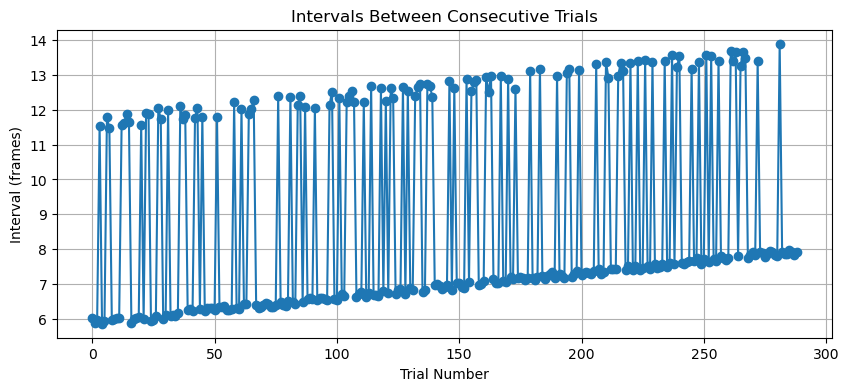

290
Generated trial_onsets_wf.npy for 20250902-175758
Shapes match.
[ 6.0064  5.8863  5.9621 11.53    5.855   5.9259 11.7925 11.4651  5.9528
  5.991   6.0277  6.007  11.5753 11.621  11.8934 11.6638  5.8892  5.9988
  6.0144  6.0384 11.57    5.9801 11.8987 11.8694  5.9353  5.9706  6.068
 12.0423 11.7428  5.9849  6.1047 11.9844  6.0854  6.0952  6.0762  6.1631
 12.1251 11.7502 11.8664  6.2473  6.2709  6.2117 11.7634 12.0669  6.2919
 11.7857  6.2306  6.3049  6.3156  6.2955  6.2381 11.7896  6.3241  6.3336
  6.3544  6.2594  6.2536  6.2851 12.2163  6.3142  6.2705 12.0233  6.4257
  6.4095 11.8942 12.024  12.2935  6.3929  6.3199  6.3229  6.4029  6.4416
  6.4274  6.3355  6.3324  6.4033 12.3899  6.4702  6.395   6.3671  6.5113
 12.38    6.4775  6.4267 12.1313 12.3875  6.4739 12.0965  6.5507  6.6024
  6.5623 12.0524  6.5385  6.5927  6.5872  6.555   6.5244 12.1419 12.5201
  6.5667  6.5423 12.3537  6.7045  6.6525 12.2174 12.3985 12.5558 12.2192
  6.6302  6.6955  6.7689 12.2115  6.6357  6.7314 12.6832 

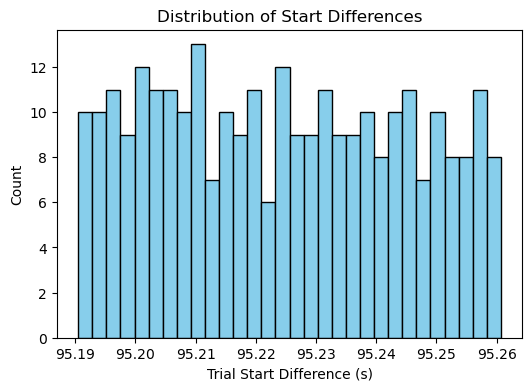

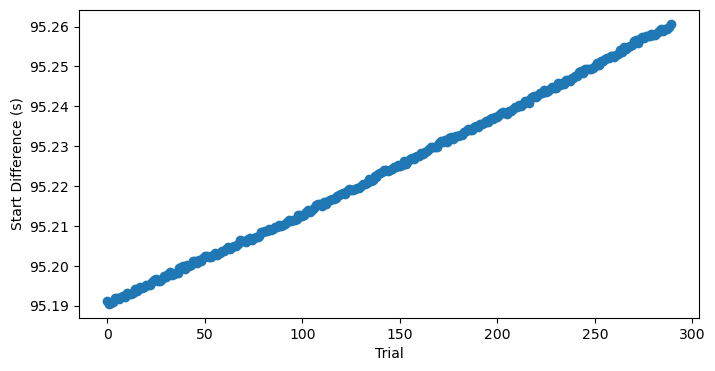

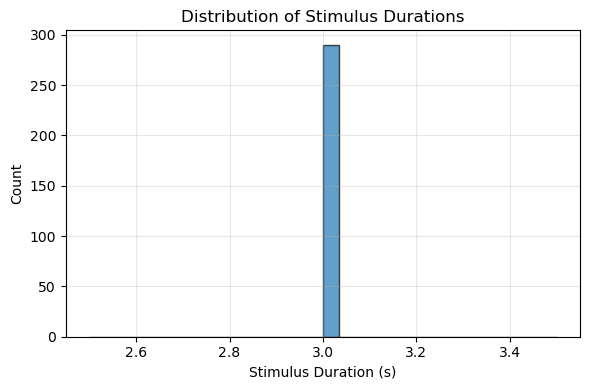

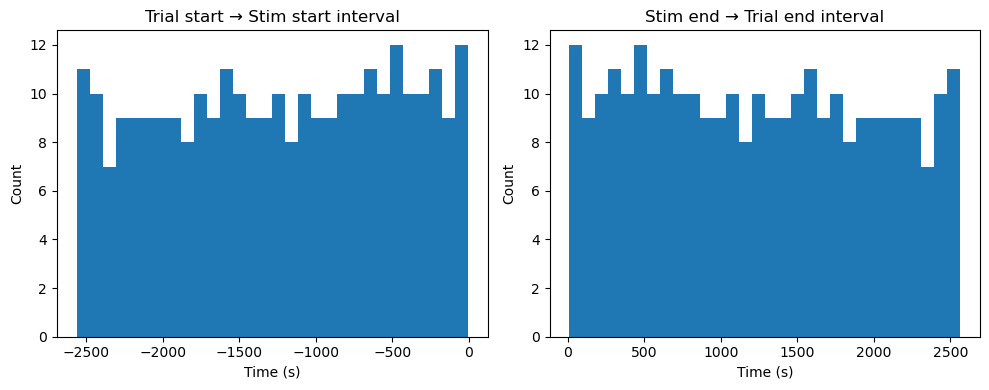

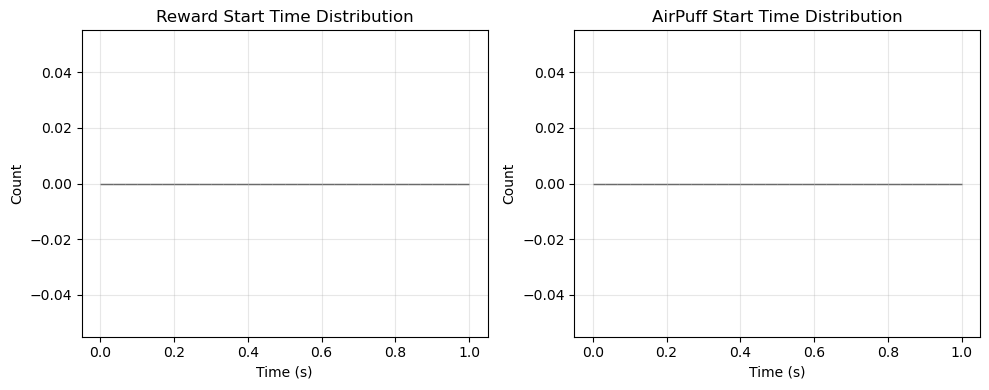

Generated stim_timestamp.npy, reward timestamps.npy, airpuff_timestamps.npy for 20250902-175758
Generated lick_timestamps.npy for 20250902-175758
Generated widefield_timestamps_blue.npy, widefield_timestamps_violet.npy for 20250902-175758
Generated all time files for 20250902-175758
----------------------------------------
/Volumes/Data_attention/Transfer learning/LinShu/DATA_linshu/000 Widefield/A095/20250905
Experiments found: ['20250905-172210']
[ 6.081 12.061 12.323  6.242  6.265  6.235  6.229  6.231  6.226  6.222
  6.198  6.122  6.045  6.023  6.029  6.076  6.187  6.28   6.233  6.309
  6.307  6.332  6.297  6.323  6.338  6.35   6.325  6.239  6.17   6.164
 12.058  6.335  6.364  6.331  6.367  6.356  6.395  6.418  6.419  6.433
  6.299  6.214  6.227  6.262  6.284  6.372  6.42   6.511  6.49   6.464
  6.496  6.459 12.748  6.509  6.482  6.316  6.313 12.288  6.423  6.54
 12.803  6.605 12.933  6.649  6.586 12.834  6.52   6.479  6.434  6.426
  6.524 12.919  6.678  6.707  6.695  6.705  6.774  

<Figure size 640x480 with 0 Axes>

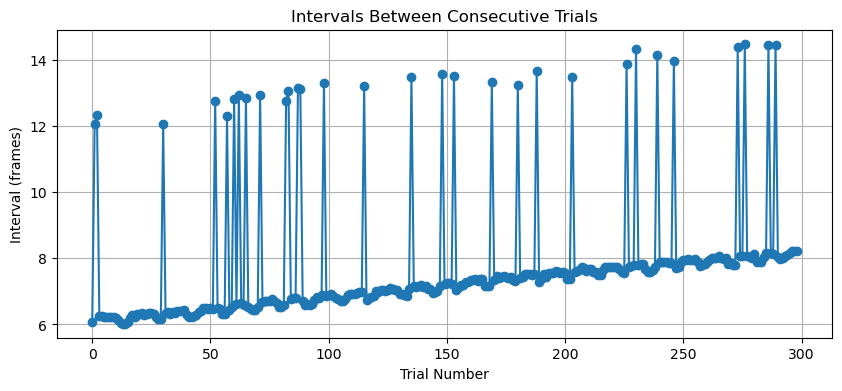

300
Generated trial_onsets_wf.npy for 20250905-172210
Shapes match.
[ 6.0809 12.0617 12.3228  6.2418  6.2659  6.2354  6.2284  6.2311  6.2265
  6.2224  6.1976  6.1227  6.0446  6.0238  6.029   6.0757  6.1878  6.2797
  6.2339  6.3086  6.3076  6.3318  6.2976  6.3226  6.3386  6.3502  6.3244
  6.2394  6.1703  6.1639 12.0589  6.335   6.3643  6.3308  6.3677  6.3563
  6.3949  6.4176  6.4194  6.433   6.2996  6.2137  6.2275  6.2626  6.2842
  6.3718  6.42    6.5115  6.4899  6.4648  6.4956  6.4592 12.7488  6.5089
  6.4817  6.317   6.3128 12.2879  6.4233  6.5408 12.8031  6.6052 12.9329
  6.6491  6.5864 12.8347  6.5202  6.4792  6.4342  6.4259  6.5243 12.9194
  6.6778  6.707   6.6953  6.7056  6.7745  6.7179  6.6616  6.5315  6.5361
  6.5786 12.7513 13.0517  6.7681  6.8031  6.8021 13.1579 13.1277  6.723
  6.5827  6.6232  6.5951  6.6127  6.734   6.8226  6.8089  6.8914 13.299
  6.8626  6.8962  6.9228  6.8714  6.8024  6.7628  6.7073  6.7209  6.761
  6.8893  6.921   6.9294  6.9368  6.9541  6.9861  6.9845 13

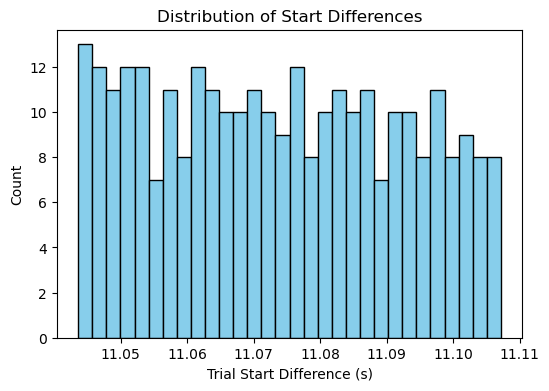

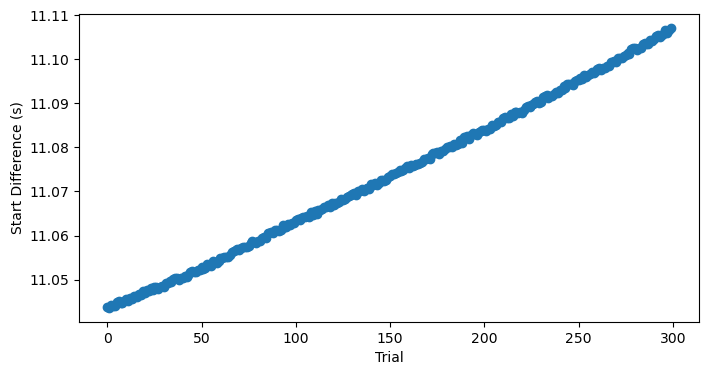

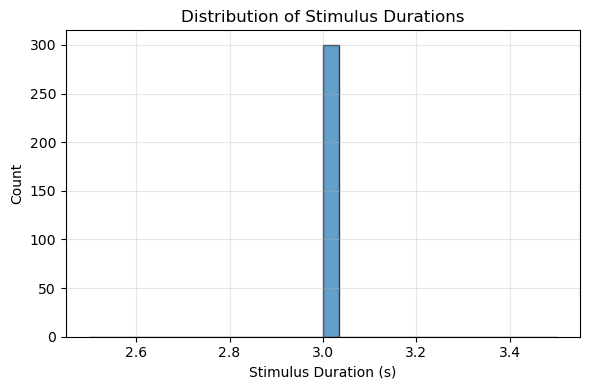

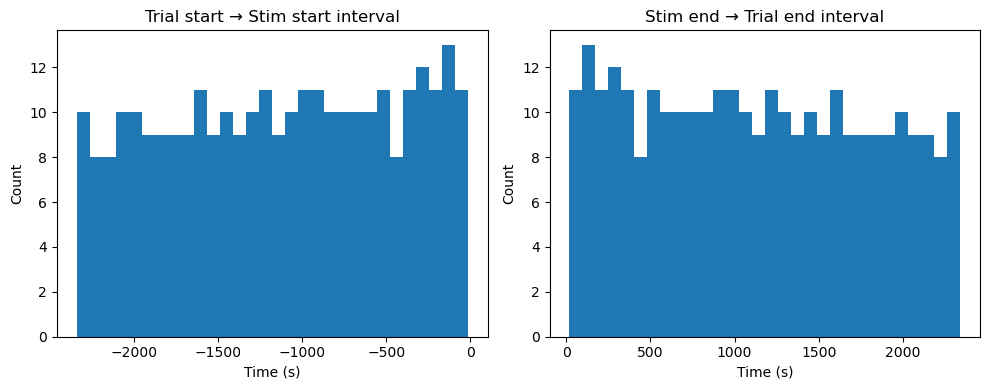

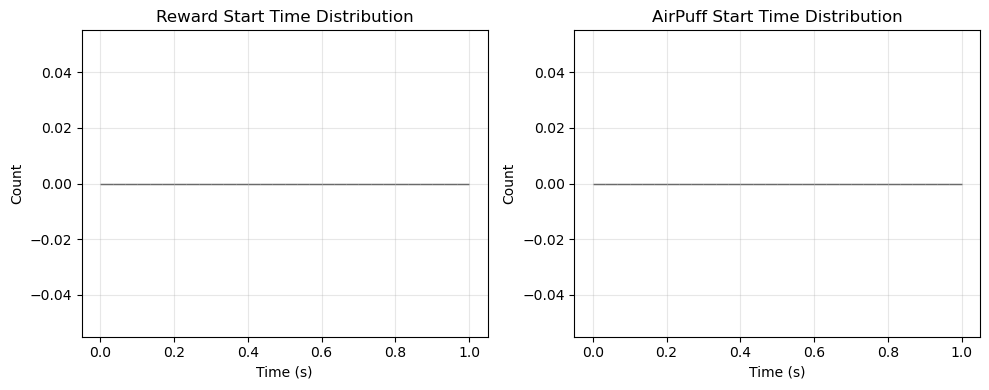

Generated stim_timestamp.npy, reward timestamps.npy, airpuff_timestamps.npy for 20250905-172210
Generated lick_timestamps.npy for 20250905-172210
Generated widefield_timestamps_blue.npy, widefield_timestamps_violet.npy for 20250905-172210
Generated all time files for 20250905-172210
----------------------------------------
all done


<Figure size 640x480 with 0 Axes>

In [10]:
config_path = pjoin(os.path.abspath('..'),'config/A095_config.yaml')   
                    #"/home/lsh/WF_GoNogo/config/A095_config.yaml"

config = load_config(config_path)
config['base_dir'] = '/Volumes/Data_attention/Transfer learning/LinShu/DATA_linshu/000 Widefield'
for session in config["sessions"]:
    if session in ['retino','20250730','20250801','20250807','20250808','20250811','20250813','20250911','20250930','20251001']:
        continue
    wf_timestamp_file =  pjoin(config['base_dir'],config['mouse_id'],session,'time/widefield_timestamps_blue.npy')
    trial_timestamp_file = pjoin(config['base_dir'],config['mouse_id'],session,'time/trial_timestamp.npy')
    if os.path.exists(wf_timestamp_file) and os.path.exists(trial_timestamp_file):
        continue
    load_timelite(config, session)
print(f"all done")

In [124]:
os.path.exists(pjoin(config['base_dir'],config['mouse_id'],'20250729','time/widefield_timestamps_blue.npy')) 

True

In [118]:
pjoin(config['base_dir'],config['mouse_id'],'A095/20250729','time/widefield_timestamps_blue.npy')

'/Volumes/Data_attention/Transfer learning/LinShu/DATA_linshu/000 Widefield/20250729/time/widefield_timestamps_blue.npy'

In [19]:
config = load_config(config_path)

In [74]:
config

{'mouse_id': 'A095',
 'birth_date': '2025-05-12',
 'base_dir': '/home/lsh/Data_attention/Transfer learning/DATA_linshu',
 'sessions': ['retino',
  '20250729',
  '20250730',
  '20250731',
  '20250801',
  '20250804',
  '20250805',
  '20250806',
  '20250807',
  '20250808',
  '20250811',
  '20250812',
  '20250813',
  '20250814',
  '20250815',
  '20250818',
  '20250819',
  '20250820',
  '20250821',
  '20250822',
  '20250825',
  '20250826',
  '20250827',
  '20250828',
  '20250829',
  '20250901',
  '20250902',
  '20250903',
  '20250904',
  '20250905',
  '20250908',
  '20250909',
  '20250910',
  '20250911',
  '20250912',
  '20250915',
  '20250916',
  '20250917',
  '20250918',
  '20250919',
  '20250922',
  '20250923',
  '20250924',
  '20250925',
  '20250926',
  '20250929',
  '20250930',
  '20251001',
  '20251002',
  '20251003',
  '20251006',
  '20251007'],
 'preprocess': {'outlier_std': 5,
  'downsample': 2,
  'svd_ncomp': 200,
  'std_level': 250,
  'chunk_size': 256,
  'hemo_correction': True}

/Volumes/Data_attention/Transfer learning/LinShu/DATA_linshu/000 Widefield/A095/retino
Experiments found: ['20250906-185140']
[15.863 15.864 15.863 15.88  15.863 15.864 15.88  15.863 15.863 15.863
 15.88  15.864 15.863 15.863 15.864 15.88  15.863 15.863 15.863 15.864
 19.466 19.45  19.466 19.45  19.466 19.45  19.466 19.45  19.466 19.449
 19.467 19.466 19.466 19.467 19.449 19.467 19.449 19.467 19.449]


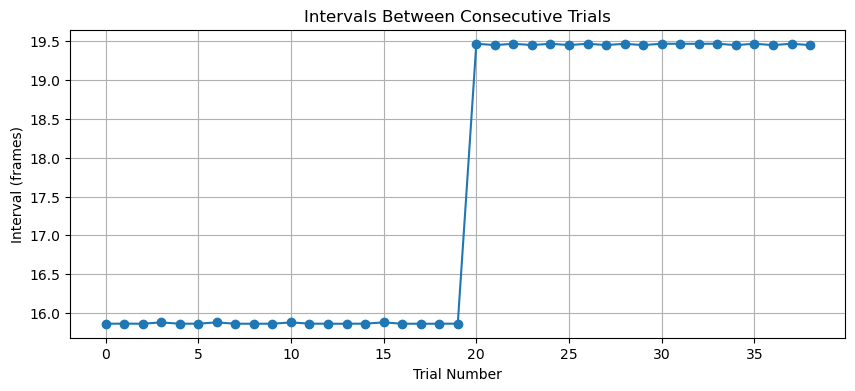

40
Generated trial_onsets_wf.npy for 20250906-185140


IndexError: list index out of range

In [72]:
preprocess_mice(config_path)

In [52]:
rawPath = '/Volumes/Data_attention/Transfer learning/linshu/DATA_linshu/A095/20250729'
items = glob(pjoin(rawPath, '202?????-??????-4*'))
print(items)
experiments = list(set([os.path.basename(item)[:15] for item in items]))
print("Experiments found:", experiments)
print(glob(pjoin(rawPath, '202*4*')))

[]
Experiments found: []
[]


In [4]:
def load_timelite(config,session):

    ## path
    rawPath = config["paths"]["raw"].format(
        base_dir=config["base_dir"], mouse_id=config["mouse_id"], session=session
    )
    processPath = config["paths"]["process"].format(
        base_dir=config["base_dir"], mouse_id=config["mouse_id"], session=session
    )
    os.makedirs(processPath, exist_ok=True)
    timePath = config["paths"]["time"].format(
        base_dir=config["base_dir"], mouse_id=config["mouse_id"], session=session
    )
    os.makedirs(timePath, exist_ok=True)
    print(rawPath)
    items = glob(pjoin(rawPath, '202?????-??????-4*'))
    experiments = list(set([os.path.basename(item)[:15] for item in items]))
    print("Experiments found:", experiments)
    for experiment in experiments:
        ## widefield trigger_onset in second
        wfieldtrigger_path = pjoin(rawPath, experiment + ".csv")
        matfile_path = glob(pjoin(rawPath,"*.mat"))
        if not (os.path.exists(wfieldtrigger_path) and len(matfile_path)>0):
            continue
        
        trial_onsets = generate_trial_onsets(wfieldtrigger_path, timePath)
        print(f"Generated trial_onsets_wf.npy for {experiment}")

        ## Bpod trial_onset in second
        matfile_path = glob(pjoin(rawPath,"*.mat"))
        mat_data = sio.loadmat(matfile_path[0], squeeze_me=True, struct_as_record=False)
        trial_timestamps = load_bpod_timestamps(mat_data, trial_onsets, timePath)
        print(f"Generated trial_timestamp.npy for {experiment}")

        ## Bpod stim onset, offset, reward time and airpuff time in second
        stim_timestamp, reward_timestamps, airpuff_timestamps = load_bpod_stim(mat_data, timePath, trial_timestamps)
        print(f"Generated stim_timestamp.npy, reward timestamps.npy, airpuff_timestamps.npy for {experiment}")

        ## Bpod lick time in second
        lick_timestamps = load_lick_time(mat_data, timePath)
        print(f"Generated lick_timestamps.npy for {experiment}")

        ## widefield frame time in second
        widetime_path_blue = pjoin(rawPath, experiment + "-470Timestamp.csv")
        widetime_path_violet = pjoin(rawPath, experiment + "-405Timestamp.csv")
        
        widefield_timestamps_blue = load_widefield_time(widetime_path_blue)
        widefield_timestamps_violet = load_widefield_time(widetime_path_violet)
        np.save(pjoin(timePath, 'widefield_timestamps_blue.npy'), widefield_timestamps_blue)
        np.save(pjoin(timePath, 'widefield_timestamps_violet.npy'), widefield_timestamps_violet)
        print(f"Generated widefield_timestamps_blue.npy, widefield_timestamps_violet.npy for {experiment}")
        print(f'Generated all time files for {experiment}')
        print('----------------------------------------')


In [102]:
rawPath = '/Volumes/Data_attention/Transfer learning/LinShu/DATA_linshu/000 Widefield/A095/20250729'
wfieldtrigger_path = pjoin('/Volumes/Data_attention/Transfer learning/LinShu/DATA_linshu/000 Widefield/A095/20250729', "20250730-215229.csv")
print(wfieldtrigger_path)
os.path.exists(wfieldtrigger_path)
matfile_path = glob(pjoin(rawPath,"*.mat"))
print(matfile_path)

/Volumes/Data_attention/Transfer learning/LinShu/DATA_linshu/000 Widefield/A095/20250729/20250730-215229.csv
['/Volumes/Data_attention/Transfer learning/LinShu/DATA_linshu/000 Widefield/A095/20250729/A095_20250729_225654_Data_.mat']


In [5]:
def generate_trial_onsets(wfieldtrigger_path, timePath):
    
    stimfile = np.loadtxt(wfieldtrigger_path, delimiter=',')
    stim_signal = stimfile[:, 0] 
    onset_indices = (np.where(np.diff(stim_signal) == 1)[0] + 1)/1000

    start_intervals = np.diff(onset_indices)
    print(start_intervals)
    plt.figure(figsize=(10, 4))
    plt.plot(start_intervals, marker='o')
    plt.xlabel('Trial Number')
    plt.ylabel('Interval (frames)')
    plt.title('Intervals Between Consecutive Trials')
    plt.grid(True)
    plt.show()
    
    print((len(onset_indices)))
    trial_onsets = onset_indices
    np.save(pjoin(timePath, 'trial_onsets_wfield.npy'), trial_onsets)
    return trial_onsets


In [6]:
def load_widefield_time(wfieldtime_path):
    
    df = pd.read_csv(wfieldtime_path, header=None)  
    stimfile = df.to_numpy().flatten() 

    return stimfile

In [7]:
from matplotlib.pyplot import savefig

def load_bpod_timestamps(mat_data, trial_onsets, timePath) :
    session = mat_data['SessionData']
    trial_start_byBpod = session.TrialStartTimestamp
    trial_end_byBpod = session.TrialEndTimestamp
    if trial_start_byBpod.shape == trial_end_byBpod.shape:
        print("Shapes match.")
    else:
        print("Shapes do NOT match.")

    trial_interval_byBpod = trial_end_byBpod - trial_start_byBpod
    start_intervals_byBpod = np.diff(trial_start_byBpod)
    print(start_intervals_byBpod)

    start_diff = trial_start_byBpod - trial_onsets

    plt.figure(figsize=(6,4))
    plt.hist(start_diff, bins=30, color='skyblue', edgecolor='k')
    plt.xlabel('Trial Start Difference (s)')
    plt.ylabel('Count')
    plt.title('Distribution of Start Differences')
    savefig(pjoin(timePath, 'QC-Start_Difference_Histogram.png'))

    plt.figure(figsize=(8,4))
    plt.plot(start_diff, marker='o', linestyle='-')
    plt.xlabel('Trial')
    plt.ylabel('Start Difference (s)') 
    trial_end = trial_onsets + trial_interval_byBpod
    trial_timestamp = np.column_stack((trial_onsets, trial_end))  # [trial_start, trial_end]*n_trial
    np.save(pjoin(timePath, 'trial_timestamp.npy'), trial_timestamp)

    return trial_timestamp

In [8]:
def load_bpod_stim(mat_data, timePath, trial_timestamp):
    session = mat_data["SessionData"]
    n_trials = int(session.nTrials)
    ## stim onset and offset
    stim_timestamp = np.full((n_trials, 2), np.nan)  # shape: (n_trials, 2)
    for i in range(n_trials):
        try:
            trial = session.RawEvents.Trial[i].Events
            start = getattr(trial, "GlobalTimer1_Start", np.nan)
            end = getattr(trial, "GlobalTimer1_End", np.nan)
        except Exception as e:
            print(f"Trial {i+1}: missing or error ({e})")
            start, end = np.nan, np.nan

        stim_timestamp[i, 0] = start
        stim_timestamp[i, 1] = end
    
    np.save(pjoin(timePath, 'stim_timestamp.npy'), stim_timestamp)

    ## QC plot for stim duration
    stim_durations = stim_timestamp[:, 1] - stim_timestamp[:, 0]
    stim_durations = stim_durations[~np.isnan(stim_durations)]
    plt.figure(figsize=(6,4))
    plt.hist(stim_durations, bins=30, edgecolor='black', alpha=0.7)
    plt.xlabel("Stimulus Duration (s)")
    plt.ylabel("Count")
    plt.title("Distribution of Stimulus Durations")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


    pre_stim_interval = stim_timestamp[:, 0] - trial_timestamp[:, 0]
    post_stim_interval = trial_timestamp[:, 1] - stim_timestamp[:, 1]
    plt.figure(figsize=(10, 4))

    plt.subplot(1, 2, 1)
    plt.hist(pre_stim_interval, bins=30)
    plt.title("Trial start → Stim start interval")
    plt.xlabel("Time (s)")
    plt.ylabel("Count")

    plt.subplot(1, 2, 2)
    plt.hist(post_stim_interval, bins=30)
    plt.title("Stim end → Trial end interval")
    plt.xlabel("Time (s)")
    plt.ylabel("Count")

    plt.tight_layout()
    plt.show()

    ## reward time and airpuff time
    reward_timestamps = np.full((n_trials, 2), np.nan)
    airpuff_timestamps = np.full((n_trials, 2), np.nan)
    for i in range(n_trials):
        trial_events = session.RawEvents.Trial[i].States  

        reward = getattr(trial, "Reward", np.array([np.nan, np.nan]))
        reward = np.asarray(reward, dtype=float).flatten()
        if reward.size < 2:
            reward = np.pad(reward, (0, 2 - reward.size), constant_values=np.nan)
        reward_timestamps[i] = reward[:2]

        airpuff = getattr(trial, "AirPuff", np.array([np.nan, np.nan]))
        airpuff = np.asarray(airpuff, dtype=float).flatten()
        if airpuff.size < 2:
            airpuff = np.pad(airpuff, (0, 2 - airpuff.size), constant_values=np.nan)
        airpuff_timestamps[i] = airpuff[:2]

    np.save(os.path.join(timePath, 'reward.npy'), reward_timestamps)
    np.save(os.path.join(timePath, 'airpuff.npy'), airpuff_timestamps)
    
    ## QC plot for reward and airpuff distribution
    plt.figure(figsize=(10, 4))

    ## Reward distribution
    plt.subplot(1, 2, 1)
    plt.hist(reward_timestamps[:, 0][~np.isnan(reward_timestamps[:, 0])], bins=30, color='green', alpha=0.7, edgecolor='black')
    plt.title("Reward Start Time Distribution")
    plt.xlabel("Time (s)")
    plt.ylabel("Count")
    plt.grid(alpha=0.3)

    # AirPuff distribution
    plt.subplot(1, 2, 2)
    plt.hist(airpuff_timestamps[:, 0][~np.isnan(airpuff_timestamps[:, 0])], bins=30, color='red', alpha=0.7, edgecolor='black')
    plt.title("AirPuff Start Time Distribution")
    plt.xlabel("Time (s)")
    plt.ylabel("Count")
    plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()
    
    savefig(pjoin(timePath, 'QC-Reward_Airpuff_Distribution.png'))


    return stim_timestamp, reward_timestamps, airpuff_timestamps

In [9]:
def load_lick_time(mat_data, timePath):
    session = mat_data["SessionData"]
    n_trials = int(session.nTrials)
    ## lick times
    lick_timestamps = []
    for i in range(n_trials):
        trial = session.RawEvents.Trial[i].Events
        licks = getattr(trial, "BNC1High", np.array([]))
        licks = np.asarray(licks, dtype=float).flatten()
        lick_timestamps.append(licks)
    np.save(pjoin(timePath, 'lick_timestamps.npy'), np.array(lick_timestamps, dtype=object))

    
    return lick_timestamps